In [229]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

torch.set_default_dtype(torch.float64)

k_true = 0.05
x_env = 20.0
initial_temp = 90.0
sigma_obs = 4.0
n = 20
T = 60.0

def newton_cooling(k, x_env, x0, t):
    return x_env + (x0 - x_env) * np.exp(-k * t)

rng = np.random.RandomState(0)
t_obs_np = np.linspace(0, T, n)
x_true_np = newton_cooling(k_true, x_env, initial_temp, t_obs_np)
y_obs_np = x_true_np + rng.normal(0, sigma_obs, size=n)

t_obs = torch.tensor(t_obs_np)
y_obs = torch.tensor(y_obs_np)

print(f"n={n}, t range=[{t_obs_np[0]:.1f}, {t_obs_np[-1]:.1f}]")

n=20, t range=[0.0, 60.0]


In [230]:
def rbf_kernel(t1, t2, sigma_f2, l):
    sqdist = (t1.unsqueeze(1) - t2.unsqueeze(0))**2
    return sigma_f2 * torch.exp(-0.5 * sqdist / l**2)

In [231]:
def k_d1(u, sigma_f2, l):
    return -(u/l**2) * rbf_kernel_from_u(u, sigma_f2, l)

def k_d2(u, sigma_f2, l):
    return (u**2/l**4 - 1/l**2) * rbf_kernel_from_u(u, sigma_f2, l)

def rbf_kernel_from_u(u, sigma_f2, l):
    return sigma_f2 * torch.exp(-0.5 * u**2 / l**2)

def pairwise_diff(t1, t2):
    return t1.unsqueeze(1) - t2.unsqueeze(0)

def build_covariance_blocks(t, sigma_f2, l):
    u = pairwise_diff(t, t)

    C_xx = rbf_kernel_from_u(u, sigma_f2, l)
    C_xdotx = k_d1(u, sigma_f2, l)      # cov(xdot, x')
    C_xxdot = -k_d1(u, sigma_f2, l)     # cov(x, xdot')
    C_xdotxdot = -k_d2(u, sigma_f2, l)  # cov(xdot, xdot')

    return {'xx': C_xx, 'xxdot': C_xxdot, 'xdotx': C_xdotx, 'xdotxdot': C_xdotxdot}

In [232]:
sf2_test = torch.tensor(1.0)
l_test = torch.tensor(10.0)

C_test = build_covariance_blocks(t_obs, sf2_test, l_test)
for key, mat in C_test.items():
    print(f"{key}: shape={mat.shape}, symmetric={'yes' if key in ('xx','xdotxdot') else 'n/a (cross-term)'}")

print("C_xx diagonal (should be all sigma_f2=1.0):", torch.diagonal(C_test['xx'])[:5])

xx: shape=torch.Size([20, 20]), symmetric=yes
xxdot: shape=torch.Size([20, 20]), symmetric=n/a (cross-term)
xdotx: shape=torch.Size([20, 20]), symmetric=n/a (cross-term)
xdotxdot: shape=torch.Size([20, 20]), symmetric=yes
C_xx diagonal (should be all sigma_f2=1.0): tensor([1., 1., 1., 1., 1.])


In [233]:
def log_likelihood_y_given_xdot(xdot, k_param, mu_x, sigma2_obs, C, rel_jitter=1e-6):
    n = len(xdot)
    I = torch.eye(n)

    jitter = rel_jitter * torch.diagonal(C['xdotxdot']).mean().abs()
    jitter = torch.clamp(jitter, min=1e-10)  # guard against a degenerate all-zero diagonal

    L_xdotxdot = torch.linalg.cholesky(C['xdotxdot'] + jitter * I)
    xdot_centered = xdot.unsqueeze(1)
    solved = torch.cholesky_solve(xdot_centered, L_xdotxdot).squeeze(1)

    mean_x_given_xdot = mu_x + C['xxdot'] @ solved
    Sigma_x_given_xdot = C['xx'] - C['xxdot'] @ torch.cholesky_solve(C['xdotx'], L_xdotxdot)

    mean_y = mean_x_given_xdot
    cov_y = Sigma_x_given_xdot + sigma2_obs * I
    cov_y = (cov_y + cov_y.T) / 2 + jitter * I

    dist = torch.distributions.MultivariateNormal(mean_y, covariance_matrix=cov_y)
    return dist

In [234]:
mu_x_test = y_obs.mean()
xdot_placeholder = torch.zeros(n)  # arbitrary test input, not yet ODE-derived

dist_test = log_likelihood_y_given_xdot(xdot_placeholder, k_true, mu_x_test, sigma_obs**2, C_test)
print("mean_y range:", dist_test.mean.min().item(), dist_test.mean.max().item())
print("cov_y diagonal range:", torch.diagonal(dist_test.covariance_matrix).min().item(),
      torch.diagonal(dist_test.covariance_matrix).max().item())

mean_y range: 45.22126069337545 45.22126069337545
cov_y diagonal range: 16.248066686032043 16.248104656128653


In [235]:
def log_posterior_k_phi_x(k_param, x, sigma_f2, l, sigma2_obs, mu_x, y_obs, t_obs):
    C = build_covariance_blocks(t_obs, sigma_f2, l)
    xdot_ode = -k_param * (x - x_env)
    dist = log_likelihood_y_given_xdot(xdot_ode, k_param, mu_x, sigma2_obs, C)
    log_lik = dist.log_prob(y_obs)
    return log_lik


In [236]:
mu_x_test = y_obs.mean()
sigma_f2_test = torch.tensor(1.0)
l_test = torch.tensor(10.0)

ll_true = log_posterior_k_phi_x(k_true, y_obs, sigma_f2_test, l_test, sigma_obs**2, mu_x_test, y_obs, t_obs)
ll_wrong1 = log_posterior_k_phi_x(0.02, y_obs, sigma_f2_test, l_test, sigma_obs**2, mu_x_test, y_obs, t_obs)
ll_wrong2 = log_posterior_k_phi_x(0.15, y_obs, sigma_f2_test, l_test, sigma_obs**2, mu_x_test, y_obs, t_obs)

print(f"log-lik at true k=0.05:  {ll_true.item():.2f}")
print(f"log-lik at wrong k=0.02: {ll_wrong1.item():.2f}")
print(f"log-lik at wrong k=0.15: {ll_wrong2.item():.2f}")

log-lik at true k=0.05:  -632.25
log-lik at wrong k=0.02: -239.33
log-lik at wrong k=0.15: -6446.38


In [237]:
k_grid = torch.arange(0.01, 0.15+1e-9, 0.005)

theta_prior_dist_literal = torch.distributions.Gamma(concentration=4.0, rate=0.5)
log_probs_literal = theta_prior_dist_literal.log_prob(k_grid)
print("Literal paper Gamma(4,0.5) log-probs across k_grid:")
print(f"  min={log_probs_literal.min().item():.2f}, max={log_probs_literal.max().item():.2f}")

Literal paper Gamma(4,0.5) log-probs across k_grid:
  min=-18.38, max=-10.33


In [238]:
theta_prior_dist = torch.distributions.Gamma(concentration=1.5, rate=20.0)
log_probs_rescaled = theta_prior_dist.log_prob(k_grid)
print("Rescaled Gamma(1.5, 20) log-probs across k_grid:")
print(f"  min={log_probs_rescaled.min().item():.2f}, max={log_probs_rescaled.max().item():.2f}")
print(f"  mode = {(1.5-1)/20:.4f}  (target: near k_true={k_true})")

Rescaled Gamma(1.5, 20) log-probs across k_grid:
  min=0.67, max=2.27
  mode = 0.0250  (target: near k_true=0.05)


In [278]:
theta_prior_dist = torch.distributions.Gamma(concentration=1.5, rate=20.0)
def log_prior_theta(k):
    return theta_prior_dist.log_prob(torch.tensor(k)).item()

sigma_prior_dist = torch.distributions.Gamma(concentration=1.0, rate=1.0)
sigma_f2_grid = torch.linspace(20.0, 180.0, 12)   # centered on the confirmed ~89 peak, wide enough to move,
                                                    # stops short of the >300 region where the ridge dominated
l_grid = torch.linspace(2.0, 30.0, 12)             # centered on the confirmed l=6 peak, spans enough of the
                                                    # smooth falloff on both sides to let the sampler actually explore
sigma2_grid = torch.arange(1.0, 30.0 + 1e-9, 1.0)  # unchanged -- never implicated in any of this

def log_prior_phi(sigma_f2, l, sigma2):
    log_p_sf2 = 0.0 if 0 < sigma_f2 < 180 else -float('inf')
    log_p_l   = 0.0 if 0 < l < 30 else -float('inf')
    sigma = np.sqrt(sigma2)
    log_p_sigma = sigma_prior_dist.log_prob(torch.tensor(sigma)).item()
    return log_p_sf2 + log_p_l + log_p_sigma

mu_x = y_obs.mean()

print(f"sigma_f2_grid=[{sigma_f2_grid[0]:.2f}, {sigma_f2_grid[-1]:.2f}]")
print(f"l_grid=[{l_grid[0]:.2f}, {l_grid[-1]:.2f}]  (floor set empirically, not from spacing heuristic)")

sigma_f2_grid=[20.00, 180.00]
l_grid=[2.00, 30.00]  (floor set empirically, not from spacing heuristic)


In [279]:
def log_gp_prior_x(x, sigma_f2, l, mu_x, rel_jitter=1e-6):
    C = build_covariance_blocks(t_obs, torch.tensor(sigma_f2), torch.tensor(l))
    n = len(x)
    jitter = rel_jitter * sigma_f2
    Cxx_j = C['xx'] + jitter * torch.eye(n)
    dist = torch.distributions.MultivariateNormal(mu_x * torch.ones(n), covariance_matrix=Cxx_j)
    return dist.log_prob(x).item()


def log_posterior_full(k_param, sigma_f2, l, sigma2, x, y_obs, t_obs):
    log_lik = log_posterior_k_phi_x(k_param, x, torch.tensor(sigma_f2), torch.tensor(l), sigma2, mu_x, y_obs, t_obs)
    log_prior_x = log_gp_prior_x(x, sigma_f2, l, mu_x)
    return log_lik.item() + log_prior_x + log_prior_theta(k_param) + log_prior_phi(sigma_f2, l, sigma2)

In [280]:
n_bins_x = 20
x_bandwidth = 3 * sigma_obs

def x_grid_at(idx):
    center = y_obs[idx]
    return torch.linspace(center - x_bandwidth, center + x_bandwidth, n_bins_x)

print(x_grid_at(0))

tensor([ 85.0562,  86.3194,  87.5825,  88.8457,  90.1088,  91.3720,  92.6352,
         93.8983,  95.1615,  96.4246,  97.6878,  98.9509, 100.2141, 101.4773,
        102.7404, 104.0036, 105.2667, 106.5299, 107.7931, 109.0562])


In [281]:
def sample_phi_given(k_param, sigma_f2, l, sigma2, x_current, t_obs, y_obs):
    """Step (a): Phi ~ p(Phi | X, theta, Y) -- sigma_f2, l, sigma2 in turn, theta fixed."""
    log_probs = torch.tensor([
        log_posterior_full(k_param, sf.item(), l, sigma2, x_current, y_obs, t_obs)
        for sf in sigma_f2_grid
    ])
    sigma_f2 = sigma_f2_grid[torch.multinomial(torch.softmax(log_probs, dim=0), 1)].item()

    log_probs = torch.tensor([
        log_posterior_full(k_param, sigma_f2, lg.item(), sigma2, x_current, y_obs, t_obs)
        for lg in l_grid
    ])
    l = l_grid[torch.multinomial(torch.softmax(log_probs, dim=0), 1)].item()

    log_probs = torch.tensor([
        log_posterior_full(k_param, sigma_f2, l, s2.item(), x_current, y_obs, t_obs)
        for s2 in sigma2_grid
    ])
    sigma2 = sigma2_grid[torch.multinomial(torch.softmax(log_probs, dim=0), 1)].item()

    return sigma_f2, l, sigma2


def sample_theta_given(k_param, sigma_f2, l, sigma2, x_current, t_obs, y_obs):
    """Step (b): theta ~ p(theta | X, Phi, Y) -- Phi fixed (just updated in step a)."""
    log_probs = torch.tensor([
        log_posterior_full(kk.item(), sigma_f2, l, sigma2, x_current, y_obs, t_obs)
        for kk in k_grid
    ])
    k_param = k_grid[torch.multinomial(torch.softmax(log_probs, dim=0), 1)].item()
    return k_param


def gibbs_sweep_k_phi(x_current, k_param, sigma_f2, l, sigma2, t_obs, y_obs, L_p=1):
    """Paper Section 3.1: for j=1:L_p, (a) Phi | theta, then (b) theta | Phi."""
    for _ in range(L_p):
        sigma_f2, l, sigma2 = sample_phi_given(k_param, sigma_f2, l, sigma2, x_current, t_obs, y_obs)
        k_param = sample_theta_given(k_param, sigma_f2, l, sigma2, x_current, t_obs, y_obs)
    return k_param, sigma_f2, l, sigma2

In [282]:
import time
x_test = y_obs.clone()

t0 = time.time()
k_new, sf2_new, l_new, s2_new = gibbs_sweep_k_phi(x_test, k_true, 1.0, 10.0, sigma_obs**2, t_obs, y_obs)
t1 = time.time()

print(f"one param sweep: {t1-t0:.3f}s")
print(f"k: {k_true} -> {k_new:.4f}")
print(f"sigma_f2: 1.0 -> {sf2_new:.4f}")
print(f"l: 10.0 -> {l_new:.4f}")
print(f"sigma2: {sigma_obs**2} -> {s2_new:.4f}")

one param sweep: 0.086s
k: 0.05 -> 0.0700
sigma_f2: 1.0 -> 165.4545
l: 10.0 -> 2.0000
sigma2: 16.0 -> 1.0000


In [283]:
def gp_prior_conditional_at_t(idx, x_current, mu_x, C, rel_jitter=1e-6):
    n = len(x_current)
    idx_others = [i for i in range(n) if i != idx]

    C_kk = C['xx'][idx, idx]
    C_k_others = C['xx'][idx, idx_others]
    C_others_others = C['xx'][idx_others][:, idx_others]

    jitter = rel_jitter * torch.diagonal(C['xx']).mean().abs()
    jitter = torch.clamp(jitter, min=1e-10)

    L = torch.linalg.cholesky(C_others_others + jitter * torch.eye(n-1))
    x_others_centered = (x_current[idx_others] - mu_x).unsqueeze(1)
    solved = torch.cholesky_solve(x_others_centered, L).squeeze(1)

    mean_k = mu_x + C_k_others @ solved
    var_k = C_kk - C_k_others @ torch.cholesky_solve(C_k_others.unsqueeze(1), L).squeeze(1)
    var_k = torch.clamp(var_k, min=jitter)

    return mean_k, var_k


def sample_x_at_t(idx, x_current, k_param, sigma_f2, l, sigma2, mu_x, t_obs, y_obs):
    grid = x_grid_at(idx)
    C = build_covariance_blocks(t_obs, torch.tensor(sigma_f2), torch.tensor(l))

    mean_k, var_k = gp_prior_conditional_at_t(idx, x_current, mu_x, C)
    prior_dist = torch.distributions.Normal(mean_k, torch.sqrt(var_k))

    log_probs = []
    for x_val in grid:
        x_proposal = x_current.clone()
        x_proposal[idx] = x_val

        log_prior = prior_dist.log_prob(x_val)
        log_lik = log_posterior_k_phi_x(k_param, x_proposal, torch.tensor(sigma_f2), torch.tensor(l), sigma2, mu_x, y_obs, t_obs)

        log_probs.append((log_prior + log_lik).item())

    log_probs = torch.tensor(log_probs)
    probs = torch.softmax(log_probs, dim=0)
    return grid[torch.multinomial(probs, 1)].item()


def gibbs_sweep_x(x_current, k_param, sigma_f2, l, sigma2, mu_x, t_obs, y_obs):
    x_new = x_current.clone()
    for idx in range(len(x_current)):
        x_new[idx] = sample_x_at_t(idx, x_new, k_param, sigma_f2, l, sigma2, mu_x, t_obs, y_obs)
    return x_new

In [284]:
t0 = time.time()
x_val_test = sample_x_at_t(0, y_obs.clone(), k_true, 1.0, 10.0, sigma_obs**2, mu_x, t_obs, y_obs)
t1 = time.time()
print(f"one time-point update: {t1-t0:.3f}s, sampled value: {x_val_test:.4f}")

one time-point update: 0.027s, sampled value: 109.0562


In [285]:
def random_init_k_phi(seed=0):
    torch.manual_seed(seed)
    k0 = k_grid[torch.randint(len(k_grid), (1,))].item()
    sf2_0 = sigma_f2_grid[torch.randint(len(sigma_f2_grid), (1,))].item()
    l0 = l_grid[torch.randint(len(l_grid), (1,))].item()
    s2_0 = sigma2_grid[torch.randint(len(sigma2_grid), (1,))].item()
    return k0, sf2_0, l0, s2_0


def run_gibbs(L, L_p, L_x, t_obs, y_obs, mu_x, init_k, init_phi, seed=0):
    torch.manual_seed(seed)
    k_param = init_k
    sigma_f2, l, sigma2 = init_phi

    C0 = build_covariance_blocks(t_obs, torch.tensor(sigma_f2), torch.tensor(l))
    L0 = torch.linalg.cholesky(C0['xx'] + sigma2*torch.eye(len(t_obs)) + 1e-6*torch.eye(len(t_obs)))
    alpha0 = torch.cholesky_solve((y_obs - mu_x).unsqueeze(1), L0).squeeze(1)
    x = mu_x + C0['xx'] @ alpha0

    samples = {'k': [], 'sigma_f2': [], 'l': [], 'sigma2': [], 'x_snapshot': []}

    for i in range(L):
        t0 = time.time()

        k_param, sigma_f2, l, sigma2 = gibbs_sweep_k_phi(x, k_param, sigma_f2, l, sigma2, t_obs, y_obs, L_p=L_p)

        for _ in range(L_x):
            x = gibbs_sweep_x(x, k_param, sigma_f2, l, sigma2, mu_x, t_obs, y_obs)

        samples['k'].append(k_param)
        samples['sigma_f2'].append(sigma_f2)
        samples['l'].append(l)
        samples['sigma2'].append(sigma2)
        samples['x_snapshot'].append(x.clone())

        print(f"iter {i+1}/{L}  k={k_param:.4f}  sigma_f2={sigma_f2:.2f}  l={l:.2f}  sigma2={sigma2:.2f}  ({time.time()-t0:.2f}s)")

    return samples

In [293]:
init_k, sf2_0, l0, s2_0 = random_init_k_phi(seed=0)
init_phi_vals = (sf2_0, l0, s2_0)
print(f"random init: k={init_k}, phi={init_phi_vals}")

samples_test_final = run_gibbs(
    L=100, L_p=1, L_x=5,
    t_obs=t_obs, y_obs=y_obs, mu_x=mu_x,
    init_k=init_k, init_phi=init_phi_vals,
    seed=0
)

random init: k=0.045, phi=(63.63636363636363, 14.727272727272727, 1.0)
iter 1/100  k=0.0450  sigma_f2=150.91  l=14.73  sigma2=18.00  (1.18s)
iter 2/100  k=0.0500  sigma_f2=165.45  l=4.55  sigma2=11.00  (1.64s)
iter 3/100  k=0.0500  sigma_f2=165.45  l=4.55  sigma2=11.00  (1.14s)
iter 4/100  k=0.0500  sigma_f2=107.27  l=4.55  sigma2=16.00  (1.14s)
iter 5/100  k=0.0500  sigma_f2=136.36  l=4.55  sigma2=9.00  (1.08s)
iter 6/100  k=0.0500  sigma_f2=136.36  l=4.55  sigma2=13.00  (1.01s)
iter 7/100  k=0.0450  sigma_f2=121.82  l=4.55  sigma2=15.00  (1.02s)
iter 8/100  k=0.0450  sigma_f2=136.36  l=4.55  sigma2=8.00  (1.03s)
iter 9/100  k=0.0450  sigma_f2=136.36  l=4.55  sigma2=14.00  (1.02s)
iter 10/100  k=0.0450  sigma_f2=150.91  l=4.55  sigma2=18.00  (1.10s)
iter 11/100  k=0.0450  sigma_f2=165.45  l=4.55  sigma2=11.00  (1.05s)
iter 12/100  k=0.0400  sigma_f2=150.91  l=4.55  sigma2=16.00  (1.02s)
iter 13/100  k=0.0450  sigma_f2=136.36  l=4.55  sigma2=24.00  (1.02s)
iter 14/100  k=0.0450  sigma_

Continuous MLE fit: sigma_f2=2543.32, l=30.25, sigma2=10.26
(compare to discrete sampler's pinned values: l≈2.0 (floor), sigma_f2 near grid ceiling)


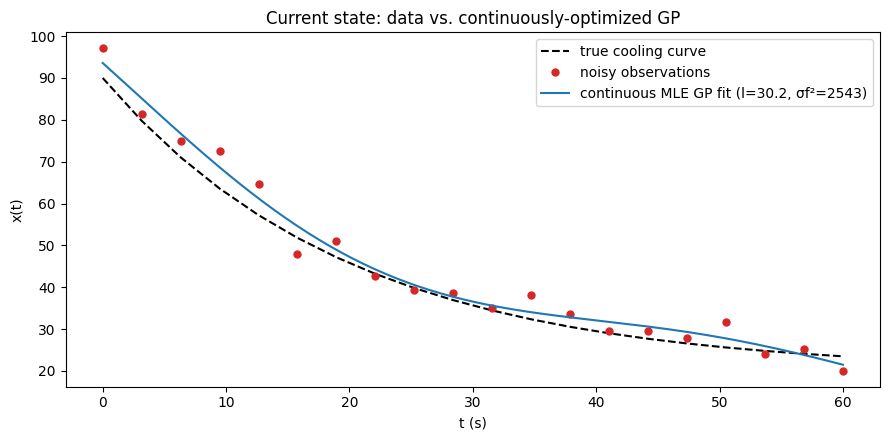

In [294]:
from scipy.optimize import minimize

def neg_log_marginal_likelihood(params, t, y, jitter=1e-6):
    sf2, l, s2 = params
    if sf2 <= 0 or l <= 0 or s2 <= 0:
        return 1e10
    C = build_covariance_blocks(t, torch.tensor(sf2), torch.tensor(l))
    n_ = len(t)
    cov = C['xx'] + s2 * torch.eye(n_) + jitter * torch.eye(n_)
    L = torch.linalg.cholesky(cov)
    alpha = torch.cholesky_solve((y - y.mean()).unsqueeze(1), L).squeeze(1)
    data_fit = 0.5 * (y - y.mean()) @ alpha
    complexity = torch.log(torch.diagonal(L)).sum()
    return (data_fit + complexity).item()

res = minimize(neg_log_marginal_likelihood, x0=[100.0, 20.0, 16.0],
                args=(t_obs, y_obs), method='Nelder-Mead')
sf2_opt, l_opt, s2_opt = res.x
print(f"Continuous MLE fit: sigma_f2={sf2_opt:.2f}, l={l_opt:.2f}, sigma2={s2_opt:.2f}")
print(f"(compare to discrete sampler's pinned values: l≈{l_grid[0].item():.1f} (floor), sigma_f2 near grid ceiling)")

C_opt = build_covariance_blocks(t_obs, torch.tensor(sf2_opt), torch.tensor(l_opt))
L_opt = torch.linalg.cholesky(C_opt['xx'] + s2_opt*torch.eye(n) + 1e-6*torch.eye(n))
alpha_opt = torch.cholesky_solve((y_obs - mu_x).unsqueeze(1), L_opt).squeeze(1)

t_grid_plot = torch.linspace(0, T, 200)
C_star = rbf_kernel(t_grid_plot, t_obs, sf2_opt, l_opt)
mean_pred = mu_x + C_star @ alpha_opt

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_obs_np, x_true_np, 'k--', label='true cooling curve')
ax.plot(t_obs_np, y_obs_np, '.', color='tab:red', markersize=10, label='noisy observations')
ax.plot(t_grid_plot, mean_pred.detach(), color='tab:blue', label=f'continuous MLE GP fit (l={l_opt:.1f}, σf²={sf2_opt:.0f})')
ax.set_xlabel('t (s)'); ax.set_ylabel('x(t)')
ax.set_title("Current state: data vs. continuously-optimized GP")
ax.legend()
plt.tight_layout()
plt.show()

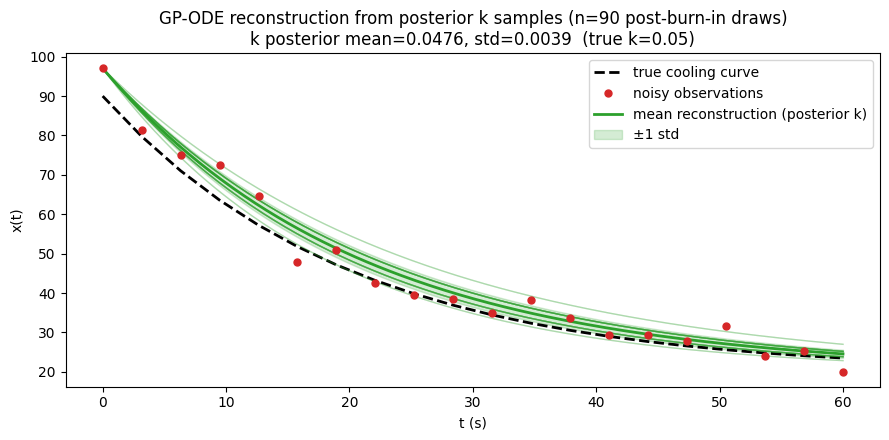

k posterior mean: 0.0476  std: 0.0039  true: 0.05


In [295]:
# Uses the closed-form solution (exact, no RK4 needed for this linear ODE) --
# same role as the paper's Figure 3 "numerically integrated curves using posterior theta samples"
def newton_cooling_pred(k, x_env, x0, t):
    return x_env + (x0 - x_env) * np.exp(-k * t)

# pick whichever samples dict is your most recent run
samples_to_plot = samples_test_final  # <-- change this to whatever your latest run variable is named

burn_in = min(10, len(samples_to_plot['k']) // 3)  # short runs need a shorter burn-in
k_samples = np.array(samples_to_plot['k'][burn_in:])

x0_for_pred = y_obs_np[0]   # anchor reconstruction at the first observed point, same convention as the paper
t_plot = np.linspace(0, T, 200)

# reconstruct one curve per posterior k sample
pred_curves = np.array([newton_cooling_pred(k, x_env, x0_for_pred, t_plot) for k in k_samples])
pred_mean = pred_curves.mean(axis=0)
pred_std = pred_curves.std(axis=0)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_obs_np, x_true_np, 'k--', linewidth=2, label='true cooling curve')
ax.plot(t_obs_np, y_obs_np, '.', color='tab:red', markersize=10, zorder=5, label='noisy observations')

# individual posterior draws, faint -- shows spread directly, same spirit as paper's green reconstructions
for curve in pred_curves[::max(1, len(pred_curves)//30)]:
    ax.plot(t_plot, curve, color='tab:green', alpha=0.15, linewidth=1)

ax.plot(t_plot, pred_mean, color='tab:green', linewidth=2, label='mean reconstruction (posterior k)')
ax.fill_between(t_plot, pred_mean - pred_std, pred_mean + pred_std, color='tab:green', alpha=0.2, label='±1 std')

ax.set_xlabel('t (s)'); ax.set_ylabel('x(t)')
ax.set_title(f'GP-ODE reconstruction from posterior k samples (n={len(k_samples)} post-burn-in draws)\n'
             f'k posterior mean={k_samples.mean():.4f}, std={k_samples.std():.4f}  (true k={k_true})')
ax.legend()
plt.tight_layout()
plt.show()

print(f"k posterior mean: {k_samples.mean():.4f}  std: {k_samples.std():.4f}  true: {k_true}")

k posterior mean: 0.0475
k posterior std:  0.0038
95% CI (empirical percentile): [0.0400, 0.0550]
true k = 0.05, inside CI: True


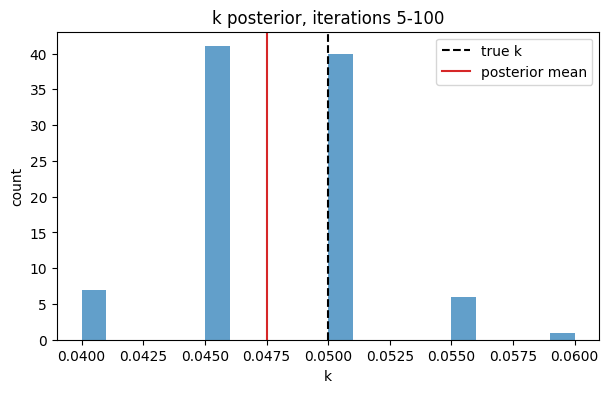

In [296]:
samples_to_plot = samples_to_plot   # <-- set to your L=200 run's variable name
burn_in = 5
k_post = np.array(samples_to_plot['k'][burn_in:])

k_mean = k_post.mean()
k_std = k_post.std()
ci_lo, ci_hi = np.percentile(k_post, [2.5, 97.5])

print(f"k posterior mean: {k_mean:.4f}")
print(f"k posterior std:  {k_std:.4f}")
print(f"95% CI (empirical percentile): [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"true k = {k_true}, inside CI: {ci_lo <= k_true <= ci_hi}")

plt.figure(figsize=(7,4))
plt.hist(k_post, bins=20, color='tab:blue', alpha=0.7)
plt.axvline(k_true, color='k', linestyle='--', label='true k')
plt.axvline(k_mean, color='tab:red', linestyle='-', label='posterior mean')
plt.xlabel('k'); plt.ylabel('count')
plt.title(f'k posterior, iterations {burn_in}-{len(samples_to_plot["k"])}')
plt.legend()
plt.show()

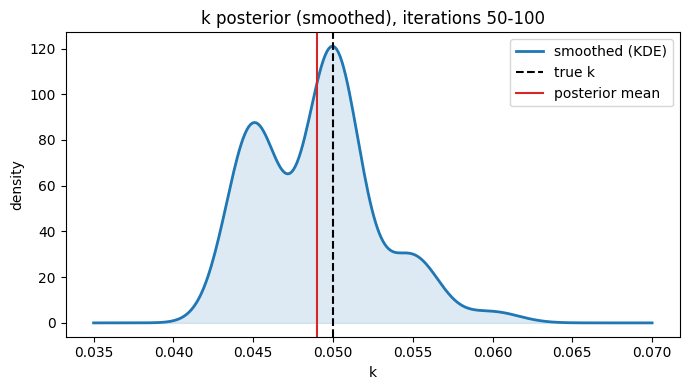

k posterior mean: 0.0490, std: 0.0036
95% CI: [0.0450, 0.0550], true k inside: True


In [299]:
from scipy.stats import gaussian_kde

samples_to_plot = samples_to_plot   # <-- your L=200 run
burn_in = 50
k_post = np.array(samples_to_plot['k'][burn_in:])

k_mean = k_post.mean()
k_std = k_post.std()
ci_lo, ci_hi = np.percentile(k_post, [2.5, 97.5])

kde = gaussian_kde(k_post)
k_range = np.linspace(k_post.min() - 0.01, k_post.max() + 0.01, 300)
density = kde(k_range)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(k_range, density, color='tab:blue', linewidth=2, label='smoothed (KDE)')
ax.fill_between(k_range, density, alpha=0.15, color='tab:blue')

ax.axvline(k_true, color='k', linestyle='--', label='true k')
ax.axvline(k_mean, color='tab:red', linestyle='-', label='posterior mean')

ax.set_xlabel('k'); ax.set_ylabel('density')
ax.set_title(f'k posterior (smoothed), iterations {burn_in}-{len(samples_to_plot["k"])}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"k posterior mean: {k_mean:.4f}, std: {k_std:.4f}")
print(f"95% CI: [{ci_lo:.4f}, {ci_hi:.4f}], true k inside: {ci_lo <= k_true <= ci_hi}")

In [226]:
# Is x actually moving across iterations, or frozen near its GP-smoothed initialization?
x_snaps = samples_to_plot['x_snapshot']
x_diffs = [torch.norm(x_snaps[i] - x_snaps[i-1]).item() for i in range(1, len(x_snaps))]

print(f"mean ||x[i] - x[i-1]||: {np.mean(x_diffs):.4f}")
print(f"max ||x[i] - x[i-1]||:  {np.max(x_diffs):.4f}")
print(f"||x[final] - x[0]||:    {torch.norm(x_snaps[-1] - x_snaps[0]).item():.4f}")

# compare x[final] directly to the raw noisy observations -- is it interpolating them almost exactly?
resid = (x_snaps[-1] - y_obs).abs()
print(f"\n|x_final - y_obs|: mean={resid.mean().item():.4f}, max={resid.max().item():.4f}, sigma_obs={sigma_obs}")

mean ||x[i] - x[i-1]||: 0.5601
max ||x[i] - x[i-1]||:  2.8245
||x[final] - x[0]||:    2.8245

|x_final - y_obs|: mean=2.3368, max=5.6842, sigma_obs=4.0


In [227]:
# does k actually respond to a DIFFERENT true value, or does it converge to ~0.05 regardless of the data?
# quick way to check without a full re-run: does the k-conditional genuinely discriminate against wrong k,
# using the REAL final state from this run (not a synthetic test point)
x_final = samples_to_plot['x_snapshot'][-1]
sf2_final = samples_to_plot['sigma_f2'][-1]
l_final = samples_to_plot['l'][-1]
s2_final = samples_to_plot['sigma2'][-1]

for k_test in [0.01, 0.03, 0.05, 0.07, 0.10, 0.15]:
    full = log_posterior_full(k_test, sf2_final, l_final, s2_final, x_final, y_obs, t_obs)
    print(f"k={k_test:.3f}  log_posterior_full={full:.2f}")

k=0.010  log_posterior_full=-397.56
k=0.030  log_posterior_full=-258.33
k=0.050  log_posterior_full=-214.46
k=0.070  log_posterior_full=-265.75
k=0.100  log_posterior_full=-521.00
k=0.150  log_posterior_full=-1421.84


In [228]:
l_test_wide = torch.linspace(1.0, 15.0, 15)
x_it = samples_to_plot['x_snapshot'][-1]   # use the real final state from your L=200 run
k_it = samples_to_plot['k'][-1]
sf2_it = samples_to_plot['sigma_f2'][-1]
s2_it = samples_to_plot['sigma2'][-1]

print("--- filling in the never-checked 1-15 range ---")
for l_val in l_test_wide:
    full = log_posterior_full(k_it, sf2_it, l_val.item(), s2_it, x_it, y_obs, t_obs)
    print(f"l={l_val.item():6.2f}  log_posterior_full={full:14.2f}")

--- filling in the never-checked 1-15 range ---
l=  1.00  log_posterior_full=       -189.35
l=  2.00  log_posterior_full=       -175.42
l=  3.00  log_posterior_full=       -146.43
l=  4.00  log_posterior_full=       -135.54
l=  5.00  log_posterior_full=       -125.35
l=  6.00  log_posterior_full=       -117.40
l=  7.00  log_posterior_full=       -122.41
l=  8.00  log_posterior_full=       -128.13
l=  9.00  log_posterior_full=       -136.77
l= 10.00  log_posterior_full=       -149.53
l= 11.00  log_posterior_full=       -164.95
l= 12.00  log_posterior_full=       -177.15
l= 13.00  log_posterior_full=       -187.63
l= 14.00  log_posterior_full=       -199.11
l= 15.00  log_posterior_full=       -214.46


In [290]:
k_arr = np.array(samples_to_plot['k'])
l_arr = np.array(samples_to_plot['l'])
sf2_arr = np.array(samples_to_plot['sigma_f2'])

print("k value counts:", {v: int(c) for v, c in zip(*np.unique(k_arr, return_counts=True))})
print(f"l values, first 10 iterations: {l_arr[:10]}")
print(f"sigma_f2 values, first 10 iterations: {sf2_arr[:10]}")
print(f"\nl unique values total: {len(np.unique(l_arr))}, sigma_f2 unique values total: {len(np.unique(sf2_arr))}")

x_snaps = samples_to_plot['x_snapshot']
x_diffs = [torch.norm(x_snaps[i] - x_snaps[i-1]).item() for i in range(1, len(x_snaps))]
print(f"\n||x[i]-x[i-1]|| for first 10 iterations: {x_diffs[:10]}")

k value counts: {0.04: 7, 0.045: 18, 0.05: 5}
l values, first 10 iterations: [14.72727273  4.54545455  4.54545455  4.54545455  4.54545455  4.54545455
  4.54545455  4.54545455  4.54545455  4.54545455]
sigma_f2 values, first 10 iterations: [150.90909091 165.45454545 165.45454545 107.27272727 136.36363636
 136.36363636 121.81818182 136.36363636 136.36363636 150.90909091]

l unique values total: 2, sigma_f2 unique values total: 5

||x[i]-x[i-1]|| for first 10 iterations: [15.521944076772014, 10.026004968244761, 15.776837048585426, 16.323597452614845, 6.684003312163178, 12.440662486479287, 13.486835686776395, 11.011955225786965, 17.5937536132852, 11.849471393238131]


In [292]:
x_it = samples_to_plot['x_snapshot'][20]   # a real, well-into-the-run state
k_it = samples_to_plot['k'][20]
sf2_it = samples_to_plot['sigma_f2'][20]
s2_it = samples_to_plot['sigma2'][20]

for l_val in l_grid:
    full = log_posterior_full(k_it, sf2_it, l_val.item(), s2_it, x_it, y_obs, t_obs)
    print(f"l={l_val.item():7.2f}  log_posterior_full={full:10.2f}")

l=   2.00  log_posterior_full=   -154.42
l=   4.55  log_posterior_full=   -122.00
l=   7.09  log_posterior_full=  -1511.72
l=   9.64  log_posterior_full= -37572.25
l=  12.18  log_posterior_full=-183760.22
l=  14.73  log_posterior_full=-241467.07
l=  17.27  log_posterior_full=-255041.92
l=  19.82  log_posterior_full=-283936.84
l=  22.36  log_posterior_full=-329050.11
l=  24.91  log_posterior_full=-363174.85
l=  27.45  log_posterior_full=-381874.96
l=  30.00  log_posterior_full=      -inf
